In [13]:
import matplotlib.pyplot as plt
import numpy as np
import cmath

vna_file1='/home/rfsoc/CCATpHive/tmp/s21_vna_1_1_20221026T053023Z.npy'
data1=np.load(vna_file1)
#freq_S1=data1[0,:]
#S1=data1[1,:]
freq_S1=data1[0]
S1=data1[1]
#f_res=np.load('/home/rfsoc/CCATpHive/tmp/f_res_targ_1_1_20221025T040339Z.npy')
vna_file2='/home/rfsoc/CCATpHive/tmp/s21_targ_1_1_20221025T112027Z.npy'
data2=np.load(vna_file2)
#freq_S1=data1[0,:]
#S1=data1[1,:]
freq_S2=data2[0]
S2=data2[1]

vna_file3='/home/rfsoc/CCATpHive/tmp/s21_targ_1_1_20221026T053320Z.npy'
data3=np.load(vna_file3)
#freq_S1=data1[0,:]
#S1=data1[1,:]
freq_S3=data3[0]
S3=data3[1]
freqs=np.load('tmp/f_res_targ_1_1_20221026T053340Z.npy', allow_pickle=True)

In [14]:
len(freqs)

5

In [15]:
def findTargMins(f, Z,stitch_bw=500, stitch_sw=100,f_hi=50, f_lo=1, prom_dB=1,
                   distance=30, width_min=5, width_max=100):
    m = np.abs(Z)

    a = m.reshape(-1, stitch_bw)               # reshape into targ bins
    f_reshaped = f.reshape(-1, stitch_bw)      # reshape into targ bins
    num_res = f_reshaped.shape[0]

    f_res = [f_reshaped[r][np.argmin(a, axis=1)[r]]for r in range(num_res)]

    return f_res

In [16]:
f_refind=findTargMins(freq_S3,S3)

In [17]:
f_refind

[(509363790.0801604+0j),
 (617799519.9383141+0j),
 (703722625.9158943+0j),
 (798591410.3597821+0j),
 (899363047.3838301+0j)]

<IPython.core.display.Javascript object>


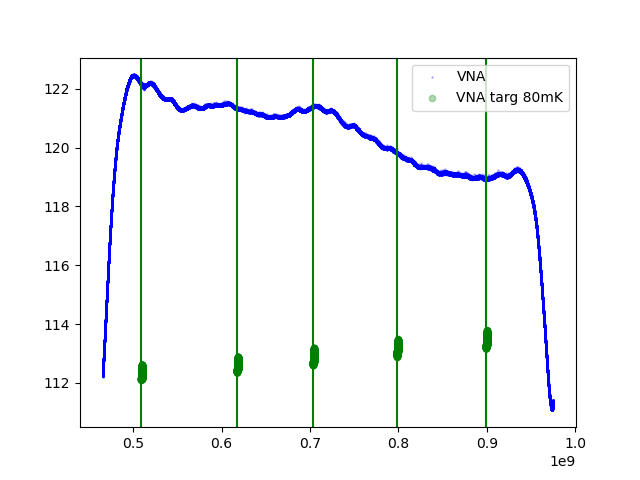

In [18]:
%matplotlib notebook
plt.scatter(freq_S1.real, 20*np.log10(np.abs(S1)), color='b',alpha=0.3, s=0.5, label='VNA')
# plt.scatter(freq_S2.real, 20*np.log10(np.abs(S2)), color='r',alpha=0.3, s=20, label='VNA targ 160 mk')
plt.scatter(freq_S3.real, 20*np.log10(np.abs(S3)), color='g',alpha=0.3, s=20, label='VNA targ 80mK')
# plt.scatter(freq_S3.real[250::500], 20*np.log10(np.abs(S3))[250::500], color='m',alpha=1, s=20, label='VNA')
plt.legend()
for freq in freqs:
    plt.axvline(freq.real, c='g')
    
#for freq in f_refind:
#    plt.axvline(freq.real,c='r')
plt.show()

In [143]:
data3.shape

(2, 2500)

In [144]:
f_res

array([5.09895134e+08+0.j, 6.18352816e+08+0.j, 7.04259968e+08+0.j,
       7.99136942e+08+0.j, 8.99926288e+08+0.j])

<IPython.core.display.Javascript object>


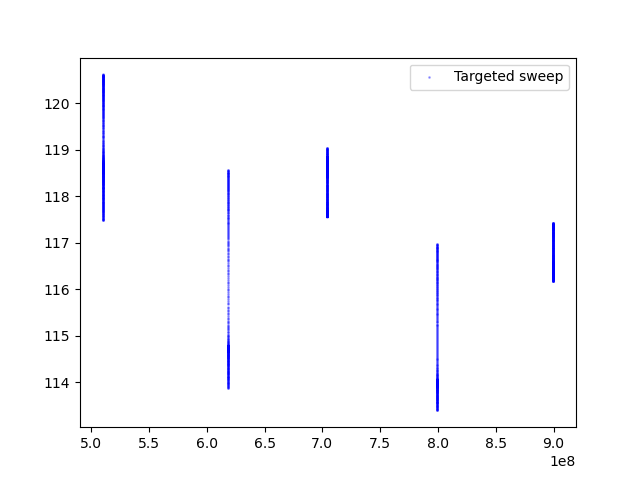

In [145]:
# Targeted sweep (command 47)
%matplotlib notebook
s21_tgt = np.load("/home/rfsoc/CCATpHive/tmp/s21_targ_1_1_20221025T200526Z.npy")
p_res_tgt = np.load("/home/rfsoc/CCATpHive/tmp/p_res_targ_1_1_20221025T200318Z.npy")
f_res_tgt = np.load("/home/rfsoc/CCATpHive/tmp/f_res_targ_1_1_20221025T200318Z.npy")
a_res_tgt = np.load("/home/rfsoc/CCATpHive/tmp/a_res_targ_1_1_20221025T200318Z.npy")
plt.scatter(s21_tgt[0].real, 20*np.log10(np.abs(s21_tgt[1].real)), color='b',alpha=0.3, s=1.0, label='Targeted sweep')
plt.legend()
# for freq in f_res_tgt:
#     plt.axvline(freq)
plt.show()

In [146]:
print(str(p_res_tgt))
print(str(f_res_tgt))
print(str(a_res_tgt))

[ 0.97834509 -2.77124933  1.96592442 -2.65870947  2.53581938]
[5.09845215e+08 6.18291016e+08 7.04207520e+08 7.99086426e+08
 8.99854980e+08]
[3663.46197094 3663.46197094 3663.46197094 3663.46197094 3663.46197094]


In [ ]:
-2.83

In [153]:
# Make the FTS just pace without collecting data

import sys
from threading import Thread
sys.path.append('/home/rfsoc/fts/')
from fts_control_script import Motor

# Worker FTS control function to run in a thread
def fts_worker_func(motor):
    motor.run_passes()
    return

passes = 10
dist = 70
speed = 10
motor = Motor(passes=passes, dist=dist, speed=speed, sample_rate=50)
motor.connect(timeout=30) # Connect to the motor over the network
print("Motor homing to start...")
motor.go_to_start() # Initialize the motor's position; takes a few seconds

motor_thread = Thread(name="motor_thread", target=fts_worker_func, kwargs={'motor':motor})
print("Motor is pacing")
motor_thread.start() # Start the FTS control thread
motor_thread.join() # Wait for it to finish
print("Motor disconnecting")
motor.disconnect() # Close the motor connection

Motor homing to start...
Motor is pacing
Motor disconnecting


In [149]:
motor.disconnect()